# Notebook 02 — Entrenamiento y Comparación de Modelos
GridSearchCV con CV=5 estratificado. Se comparan dos estrategias de manejo del desbalance:
- **Estrategia A**: `class_weight='balanced'` (sin oversampling)
- **Estrategia B**: SMOTE (datos sintéticos previamente generados)

In [1]:
import sys, os, warnings, time
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.patches import Patch

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix)
from src.models import calcular_costo_negocio, optimizar_umbral
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

SEED = 42
np.random.seed(SEED)
print('Librerías cargadas.')


Librerías cargadas.


In [2]:
# Sin SMOTE (class_weight='balanced' dentro del modelo)
X_train_bal = joblib.load('../data/processed/X_train.pkl')
y_train_bal = joblib.load('../data/processed/y_train.pkl')

# Con SMOTE
X_train_sm  = joblib.load('../data/processed/X_train_sm.pkl')
y_train_sm  = joblib.load('../data/processed/y_train_sm.pkl')

# Validación y test (siempre los originales, nunca sobremuestreados)
X_val       = joblib.load('../data/processed/X_val.pkl')
y_val       = joblib.load('../data/processed/y_val.pkl')

print(f'Train (sin SMOTE): {X_train_bal.shape} | churn rate: {y_train_bal.mean():.3f}')
print(f'Train (con SMOTE): {X_train_sm.shape}  | churn rate: {y_train_sm.mean():.3f}')
print(f'Validación       : {X_val.shape}        | churn rate: {y_val.mean():.3f}')

Train (sin SMOTE): (4507, 31) | churn rate: 0.265
Train (con SMOTE): (4734, 31)  | churn rate: 0.301
Validación       : (1127, 31)        | churn rate: 0.265


## 2. Configuración del experimento
4 algoritmos × 2 estrategias de desbalance = **8 configuraciones**.
Los modelos que aceptan `class_weight` lo usan en la versión sin SMOTE.

In [3]:
# Columnas a eliminar por alta multicolinealidad (VIF > 10)
COLS_PURGA = ['TotalCharges', 'tenure']

def purgar(X):
    return X.drop(columns=[c for c in COLS_PURGA if c in X.columns], errors='ignore')

# Aplicar depuración a todos los datasets de entrada
X_train_bal_p = purgar(X_train_bal)
X_train_sm_p  = purgar(X_train_sm)
X_val_p       = purgar(X_val)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

experimentos = [
    # ── class_weight='balanced' (sin SMOTE) ─────────────────────────────────
    {
        'nombre': 'LogReg L2    [balanced]',
        'X_train': X_train_bal_p, 'y_train': y_train_bal, 'X_val': X_val_p,
        'modelo': LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'),
        'grid': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    {
        'nombre': 'SVM RBF      [balanced]',
        'X_train': X_train_bal_p, 'y_train': y_train_bal, 'X_val': X_val_p,
        'modelo': SVC(random_state=SEED, kernel='rbf', probability=True, class_weight='balanced'),
        'grid': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
    },
    {
        'nombre': 'Rand.Forest  [balanced]',
        'X_train': X_train_bal_p, 'y_train': y_train_bal, 'X_val': X_val_p,
        'modelo': RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
        'grid': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
    },
    {
        'nombre': 'XGBoost      [scale_pos_weight]',
        'X_train': X_train_bal_p, 'y_train': y_train_bal, 'X_val': X_val_p,
        'modelo': XGBClassifier(
            random_state=SEED, eval_metric='logloss', n_jobs=-1,
            scale_pos_weight=(y_train_bal == 0).sum() / (y_train_bal == 1).sum()
        ),
        'grid': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]}
    },
    # ── SMOTE ────────────────────────────────────────────────────────────────
    {
        'nombre': 'LogReg L2    [SMOTE]',
        'X_train': X_train_sm_p, 'y_train': y_train_sm, 'X_val': X_val_p,
        'modelo': LogisticRegression(random_state=SEED, max_iter=1000),
        'grid': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    {
        'nombre': 'SVM RBF      [SMOTE]',
        'X_train': X_train_sm_p, 'y_train': y_train_sm, 'X_val': X_val_p,
        'modelo': SVC(random_state=SEED, kernel='rbf', probability=True),
        'grid': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
    },
    {
        'nombre': 'Rand.Forest  [SMOTE]',
        'X_train': X_train_sm_p, 'y_train': y_train_sm, 'X_val': X_val_p,
        'modelo': RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'grid': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
    },
    {
        'nombre': 'XGBoost      [SMOTE]',
        'X_train': X_train_sm_p, 'y_train': y_train_sm, 'X_val': X_val_p,
        'modelo': XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1),
        'grid': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]}
    },
]
print(f'Total experimentos: {len(experimentos)}')


Total experimentos: 8


## 3. Bucle de entrenamiento con GridSearchCV (cv=5, scoring=F1)

In [4]:
resultados = []
modelos_guardados = {}

print('=' * 70)
print(' TORNEO DE ALGORITMOS  |  GridSearchCV  |  cv=5  |  scoring=f1')
print('=' * 70)

for exp in experimentos:
    t0 = time.time()

    gs = GridSearchCV(exp['modelo'], exp['grid'],
                      scoring='f1', cv=cv, n_jobs=-1, verbose=0)
    gs.fit(exp['X_train'], exp['y_train'])

    modelo  = gs.best_estimator_
    y_pred  = modelo.predict(exp['X_val'])
    y_prob  = modelo.predict_proba(exp['X_val'])[:, 1]

    f1  = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    neg = calcular_costo_negocio(y_val, y_pred)
    dt  = time.time() - t0

    print(f"\n{exp['nombre']}")
    print(f"   CV-F1: {gs.best_score_:.4f}  |  Val-F1: {f1:.4f}  "
          f"|  AUC: {auc:.4f}  |  {dt:.1f}s")
    print(f"   FP: {neg['Falsos Positivos (Gastos Innecesarios)']:>4}  "
          f"FN: {neg['Falsos Negativos (Fugas No Detectadas)']:>4}  "
          f"Costo: ${neg['COSTO TOTAL ($)']:>8,.0f}  "
          f"Ahorro vs naive: ${neg['Ahorro vs. Naive ($)']:>8,.0f}")

    resultados.append({
        'Modelo': exp['nombre'],
        'F1 CV':      round(gs.best_score_, 4),
        'F1 Val':     round(f1, 4),
        'Accuracy':   round(acc, 4),
        'AUC-ROC':    round(auc, 4),
        'FP': neg['Falsos Positivos (Gastos Innecesarios)'],
        'FN': neg['Falsos Negativos (Fugas No Detectadas)'],
        'Costo ($)':  neg['COSTO TOTAL ($)'],
        'Ahorro ($)': neg['Ahorro vs. Naive ($)'],
        'Params':     gs.best_params_,
    })
    modelos_guardados[exp['nombre']] = {
        'modelo': modelo,
        'X_val':  exp['X_val'],
        'y_prob': y_prob
    }

print('\n' + '=' * 70)
print('  TORNEO FINALIZADO')
print('=' * 70)


 TORNEO DE ALGORITMOS  |  GridSearchCV  |  cv=5  |  scoring=f1

LogReg L2    [balanced]
   CV-F1: 0.6334  |  Val-F1: 0.6306  |  AUC: 0.8514  |  5.7s
   FP:  220  FN:   60  Costo: $  22,400  Ahorro vs naive: $  67,300

SVM RBF      [balanced]
   CV-F1: 0.6264  |  Val-F1: 0.6366  |  AUC: 0.8314  |  26.5s
   FP:  215  FN:   59  Costo: $  22,000  Ahorro vs naive: $  67,700

Rand.Forest  [balanced]
   CV-F1: 0.6323  |  Val-F1: 0.6367  |  AUC: 0.8458  |  8.0s
   FP:  217  FN:   58  Costo: $  21,740  Ahorro vs naive: $  67,960

XGBoost      [scale_pos_weight]
   CV-F1: 0.6352  |  Val-F1: 0.6344  |  AUC: 0.8500  |  2.8s
   FP:  209  FN:   63  Costo: $  23,080  Ahorro vs naive: $  66,620

LogReg L2    [SMOTE]
   CV-F1: 0.6380  |  Val-F1: 0.6022  |  AUC: 0.8471  |  0.4s
   FP:   91  FN:  131  Costo: $  41,120  Ahorro vs naive: $  48,580

SVM RBF      [SMOTE]
   CV-F1: 0.6427  |  Val-F1: 0.6143  |  AUC: 0.7991  |  24.7s
   FP:   98  FN:  123  Costo: $  38,860  Ahorro vs naive: $  50,840

Rand.For

## 4. Tabla comparativa y visualización

In [5]:
df_res = pd.DataFrame(resultados).sort_values('F1 Val', ascending=False).reset_index(drop=True)
display(df_res[['Modelo','F1 CV','F1 Val','Accuracy','AUC-ROC','FP','FN','Costo ($)','Ahorro ($)']])

,Modelo,F1 CV,F1 Val,Accuracy,AUC-ROC,FP,FN,Costo ($),Ahorro ($)
0,Rand.Forest [balanced],0.6323,0.6367,0.7560,0.8458,217,58,21740,67960
1,SVM RBF [balanced],0.6264,0.6366,0.7569,0.8314,215,59,22000,67700
2,XGBoost [scale_pos_weight],0.6352,0.6344,0.7587,0.8500,209,63,23080,66620
3,LogReg L2 [balanced],0.6334,0.6306,0.7516,0.8514,220,60,22400,67300
4,XGBoost [SMOTE],0.6367,0.6266,0.8181,0.8492,78,127,39660,50040
5,SVM RBF [SMOTE],0.6427,0.6143,0.8039,0.7991,98,123,38860,50840
6,LogReg L2 [SMOTE],0.6380,0.6022,0.8030,0.8471,91,131,41120,48580
7,Rand.Forest [SMOTE],0.6424,0.5974,0.8039,0.8296,86,135,42220,47480


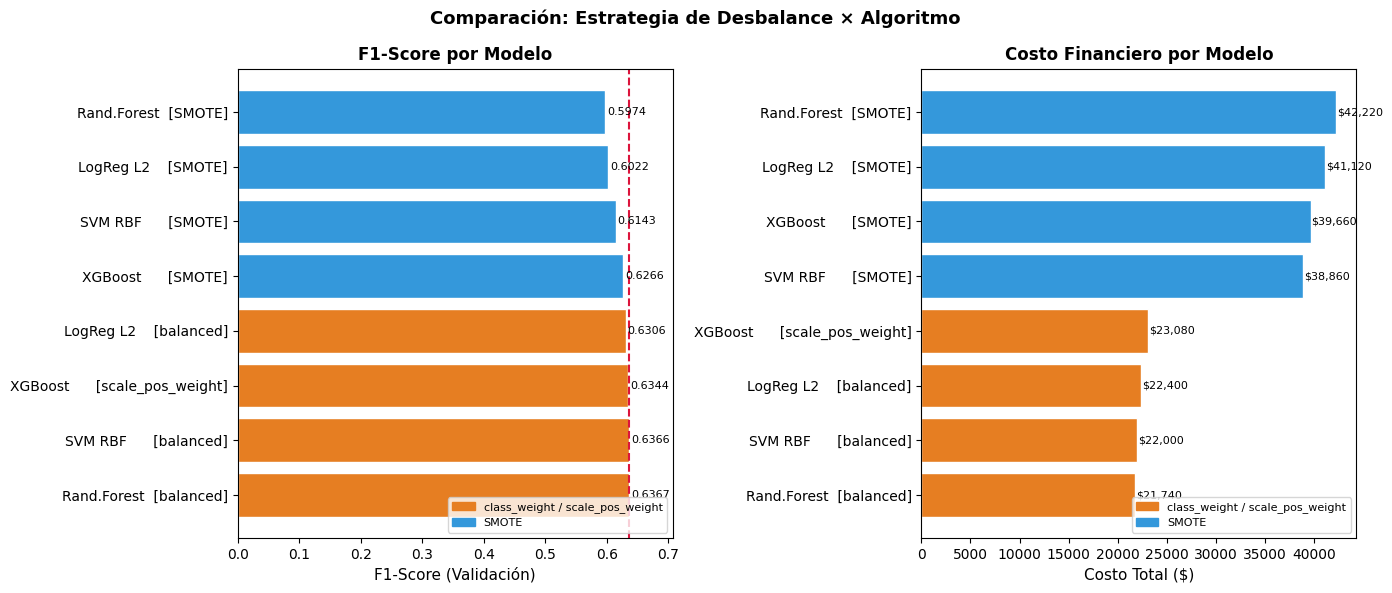

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Valor F1
colores = ['#e67e22' if 'balanced' in m or 'scale_pos' in m else '#3498db'
           for m in df_res['Modelo']]
bars = axes[0].barh(df_res['Modelo'], df_res['F1 Val'], color=colores, edgecolor='white')
axes[0].axvline(df_res['F1 Val'].max(), color='crimson', ls='--', lw=1.5)
for bar, v in zip(bars, df_res['F1 Val']):
    axes[0].text(v + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
axes[0].set_xlabel('F1-Score (Validación)', fontsize=11)
axes[0].set_title('F1-Score por Modelo', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, df_res['F1 Val'].max() + 0.07)

# Costo financiero
df_ord = df_res.sort_values('Costo ($)')
colores2 = ['#e67e22' if 'balanced' in m or 'scale_pos' in m else '#3498db'
            for m in df_ord['Modelo']]
bars2 = axes[1].barh(df_ord['Modelo'], df_ord['Costo ($)'], color=colores2, edgecolor='white')
for bar, v in zip(bars2, df_ord['Costo ($)']):
    axes[1].text(v + 100, bar.get_y() + bar.get_height()/2,
                 f'${v:,.0f}', va='center', fontsize=8)
axes[1].set_xlabel('Costo Total ($)', fontsize=11)
axes[1].set_title('Costo Financiero por Modelo', fontsize=12, fontweight='bold')

leyenda = [Patch(color='#e67e22', label='class_weight / scale_pos_weight'),
           Patch(color='#3498db', label='SMOTE')]
for ax in axes:
    ax.legend(handles=leyenda, fontsize=8, loc='lower right')

plt.suptitle('Comparación: Estrategia de Desbalance × Algoritmo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Afinación fina del modelo ganador (RandomizedSearchCV)
Búsqueda en dos etapas: el GridSearchCV anterior exploró todos los algoritmos con un grid grueso. Ahora se afina únicamente el ganador con un espacio de búsqueda más amplio y `RandomizedSearchCV`, que es más eficiente computacionalmente cuando el espacio tiene muchas dimensiones.

In [7]:
# Identificar el ganador y sus datos de entrenamiento
mejor_nombre = df_res.iloc[0]['Modelo']
mejor_info   = modelos_guardados[mejor_nombre]
X_train_best = mejor_info.get('X_train', None)

# Reconstruir X_train del ganador a partir de su nombre
if X_train_best is None:
    if '[balanced]' in mejor_nombre or '[scale_pos_weight]' in mejor_nombre:
        X_train_best = X_train_bal_p
        y_train_best = y_train_bal
    else:
        X_train_best = X_train_sm_p
        y_train_best = y_train_sm
else:
    y_train_best = y_train_bal if '[balanced]' in mejor_nombre or '[scale_pos_weight]' in mejor_nombre else y_train_sm

X_val_best = mejor_info['X_val']

print(f'Afinando: {mejor_nombre}')
print(f'X_train: {X_train_best.shape} | X_val: {X_val_best.shape}')

# Espacios de búsqueda por tipo de modelo
if 'LogReg' in mejor_nombre:
    base_model = LogisticRegression(random_state=SEED, max_iter=2000,
                                     class_weight='balanced' if '[balanced]' in mejor_nombre else None)
    param_dist = {
        'C':        uniform(0.001, 100),
        'penalty':  ['l2', 'l1', 'elasticnet'],
        'solver':   ['saga'],
        'l1_ratio': uniform(0, 1),   # solo aplica para elasticnet
    }

elif 'SVM' in mejor_nombre:
    base_model = SVC(random_state=SEED, kernel='rbf', probability=True,
                     class_weight='balanced' if '[balanced]' in mejor_nombre else None)
    param_dist = {
        'C':     uniform(0.01, 50),
        'gamma': uniform(0.0001, 1),
    }

elif 'Forest' in mejor_nombre:
    base_model = RandomForestClassifier(random_state=SEED, n_jobs=-1,
                                         class_weight='balanced' if '[balanced]' in mejor_nombre else None)
    param_dist = {
        'n_estimators':      randint(100, 500),
        'max_depth':         [5, 8, 10, 15, None],
        'min_samples_split': randint(2, 15),
        'min_samples_leaf':  randint(1, 10),       # controla overfitting
        'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    }

else:  # XGBoost
    spw = (y_train_best == 0).sum() / (y_train_best == 1).sum() if '[scale_pos_weight]' in mejor_nombre else 1
    base_model = XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=-1,
                                scale_pos_weight=spw)
    param_dist = {
        'n_estimators':      randint(100, 500),
        'max_depth':         randint(3, 10),
        'learning_rate':     uniform(0.01, 0.3),
        'subsample':         uniform(0.6, 0.4),        # fracción de filas por árbol
        'colsample_bytree':  uniform(0.6, 0.4),        # fracción de columnas por árbol
        'reg_alpha':         uniform(0, 2),             # L1
        'reg_lambda':        uniform(1, 4),             # L2
    }

# RandomizedSearchCV
t0 = time.time()
rs = RandomizedSearchCV(
    base_model, param_dist,
    n_iter=60,            # 60 combinaciones aleatorias
    scoring='f1',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)
rs.fit(X_train_best, y_train_best)
dt = time.time() - t0

modelo_afinado = rs.best_estimator_
y_pred_af = modelo_afinado.predict(X_val_best)
y_prob_af  = modelo_afinado.predict_proba(X_val_best)[:, 1]

f1_base   = df_res.iloc[0]['F1 Val']
f1_afinado = f1_score(y_val, y_pred_af)
auc_af     = roc_auc_score(y_val, y_prob_af)
neg_af     = calcular_costo_negocio(y_val, y_pred_af)

print(f'\n── Resultados de la afinación ({dt:.1f}s) ──')
print(f'  F1 Val  GridSearch  : {f1_base:.4f}')
print(f'  F1 Val  Randomized  : {f1_afinado:.4f}  ({"↑" if f1_afinado > f1_base else "↓"} {abs(f1_afinado - f1_base):.4f})')
print(f'  AUC-ROC             : {auc_af:.4f}')
print(f'  Costo total ($)     : {neg_af["COSTO TOTAL ($)"]:.0f}')
print(f'\n  Mejores hiperparámetros:')
for k, v in rs.best_params_.items():
    print(f'    {k}: {v}')

# Decidir si el modelo afinado supera al ganador original
if f1_afinado > f1_base:
    print(f'\n El modelo afinado MEJORA el F1 ({f1_afinado:.4f} > {f1_base:.4f}). Se usará como ganador final.')
    modelo_ganador  = modelo_afinado
    X_val_ganador   = X_val_best
    y_prob_ganador  = y_prob_af
else:
    print(f'\n El modelo original mantiene mejor F1 ({f1_base:.4f} ≥ {f1_afinado:.4f}). Se conserva el ganador del GridSearch.')
    modelo_ganador  = mejor_info['modelo']
    X_val_ganador   = mejor_info['X_val']
    y_prob_ganador  = mejor_info['y_prob']


Afinando: Rand.Forest  [balanced]
X_train: (4507, 29) | X_val: (1127, 29)

── Resultados de la afinación (92.3s) ──
  F1 Val  GridSearch  : 0.6367
  F1 Val  Randomized  : 0.6425  (↑ 0.0058)
  AUC-ROC             : 0.8466
  Costo total ($)     : 24440

  Mejores hiperparámetros:
    max_depth: 8
    max_features: sqrt
    min_samples_leaf: 2
    min_samples_split: 5
    n_estimators: 191

 El modelo afinado MEJORA el F1 (0.6425 > 0.6367). Se usará como ganador final.


## 5. Exportar modelo ganador

In [8]:
joblib.dump(modelo_ganador, '../data/processed/modelo_ganador.pkl')
joblib.dump({'nombre': mejor_nombre, 'X_val': X_val_ganador},
            '../data/processed/ganador_meta.pkl')

print(f'   Ganador final : {mejor_nombre}')
print(f'   F1 Val        : {f1_score(y_val, modelo_ganador.predict(X_val_ganador)):.4f}')
print(f'   AUC-ROC       : {roc_auc_score(y_val, modelo_ganador.predict_proba(X_val_ganador)[:,1]):.4f}')
print('\n Modelo ganador exportado.')

   Ganador final : Rand.Forest  [balanced]
   F1 Val        : 0.6425
   AUC-ROC       : 0.8466

 Modelo ganador exportado.
